# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


## Question 1
**What makes a model "linear"? "Linear" in what?**

- A model is linear if it is linear in its coefficients. The coefficients have to be multiplicative constants (and are combined through addition) that are not transformed (squared, etc...). A model's input variables do not have to be linear (x^2 can still result in a linear model if the coefficients appear linearly). "Linear" refers specifically to linearity in the parameters, not in the predictors.

**How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)**

- The coefficient for a dummy (one-hot encoded) variable represents the difference in the predicted outcome relative to the omitted reference category. Because one category is dropped using drop_first=True to avoid multicollinearity, the intercept corresponds to the predicted value for that reference group (like a black car). Each dummy variable coefficient then measures how much the predicted outcome changes compared to this baseline category.

**Can linear regression be used for classification? Explain why, or why not.**

- Linear regression can technically be used for classification by treating the output as a continuous score and applying a threshold (predicting class 1 if the output is greater than 0.5). However, it is not well-suited for classification problems because it is designed to minimize mean squared error and does not constrain predictions to lie between 0 and 1. Because of this, predicted values can fall outside the range of valid probabilities, making interpretation difficult. Linear regression also does not model class probabilities appropriately, which is why there are methods like logistic regression (preferred for classification tasks). 

**What are signs that your linear model is over-fitting?**

- Some signs that your model is over-fitting is if it has a low training error and a much higher test/validation error. This indicates that it has learned noise rather than the underlying signal. This often happens when the model has too many predictors or has highly variable coefficients, which leads to the model fitting the training data closely and performing poorly on test/unseen data. 

**Clearly explain multi-colinearity using the two-stage least squares technique.**

- Multi-colinearity occurs when two or more explanatory variables are highly correlated, meaning they contain overlapping information about the response variable. They tend to cancel one another out, and give the model an unexpected "mushy" and "high variance" quality. The two-stage least squares technique can be used to explain this (partial regression).
- In the first stage, a variable of interest is regressed on all the other predictors and obtains its residuals, which represent the variation in that variable not explained by the others. If there is a strong multi-colinearity, this residual will be very small because most of the variation has already been explained by the other variables.
- In the second stage, the response variable is regressed (also residualized with respect to the other predictors) on this residual. Since the residual contains little unique variation, the resulting coefficient will be unstable and difficult to estimate precisely.
- Multi-colinearity leads to coefficients that are unreliable and sensitive to small changes in data because the model cannot clearly distinguish the individual effects of highly correlated predictors. 

**How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?**

- Nonlinear relationships can be incorporated by transforming the predictors and including these transformed variables in the feature matrix. For example, adding polynomial terms, interaction terms, or logarithmic transformations allows the model to capture curvature and more complex patterns. Even though the relationship between $x$ and $y$ becomes nonlinear, the model remains linear in its parameters, so it can still be estimated using standard linear regression techniques.

**What is the interpretation of the slope coefficient in a linear regression?**

- The slope coefficient in a linear regression represents the expected change in the response variable $y$ associated with a one-unit increase in a predictor variable $x$, holding all other variables constant. In other words, it measures the marginal effect of that predictor on the outcome. A positive coefficient indicates that $y$ increases as $x$ increases, while a negative coefficient indicates that $y$ decreases as $x$ increases

**Compare the train/test split and $k$-fold cross validation.**

- A train/test split evaluates model performance using a single partition of the data, which can lead to variability depending on the specific split. In contrast, k-fold cross validation averages performance across multiple splits, reducing variance and providing a more reliable estimate of generalization performance. However, cross validation is more computationally expensive than a single train/test split.

**How is the $k$ in $k$-fold cross validation typically selected?**

- To choose the k, it depends on the prediction environment in question. The choice of k depends on the bias-variance trade-off (one does not want to overfit/underfit) Usually, k=5 or k=10 is commonly used. k=10 is normally the standard default because it provides a reliable estimate, and it is not too expensive. 

## Question 2

**Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./data/Q1_clean.csv")
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [11]:
df.columns
df.rename(columns={"Neighbourhood ": "Neighbourhood"}, inplace=True)

In [12]:
df.groupby("Neighbourhood")[["Price", "Review Scores Rating"]].mean()

,Price,Review Scores Rating
Neighbourhood,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


- The Manhattan borough is most expensive on average

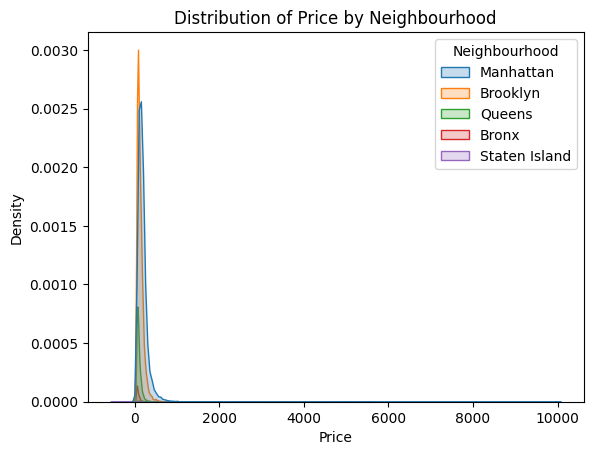

In [13]:
sns.kdeplot(x = df["Price"], hue = df["Neighbourhood"], fill = True)
plt.xlabel("Price")
plt.ylabel("Density")
plt.title("Distribution of Price by Neighbourhood")
plt.show()

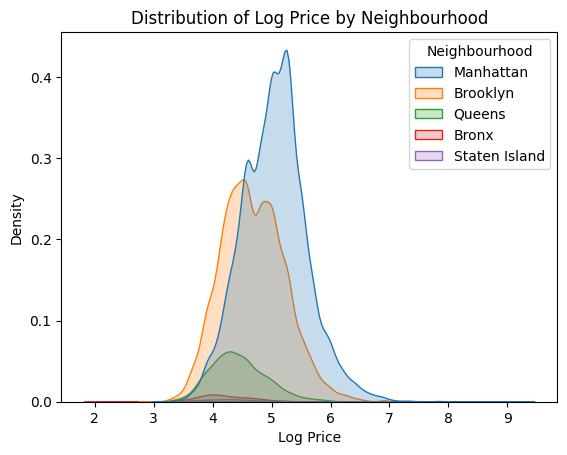

In [14]:
sns.kdeplot(x = np.log(df["Price"]), hue = df["Neighbourhood"], fill = True)
plt.xlabel("Log Price")
plt.ylabel("Density")
plt.title("Distribution of Log Price by Neighbourhood")
plt.show()

**Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?**

In [15]:
df['Neighbourhood'].value_counts()

Neighbourhood
Manhattan        11763
Brooklyn          8487
Queens            1590
Bronx              217
Staten Island       96
Name: count, dtype: int64

In [16]:
pd.get_dummies(df["Neighbourhood"].head())

,Brooklyn,Manhattan
0,False,True
1,True,False
2,False,True
3,True,False
4,False,True


In [17]:
X_Neighbourhood = pd.get_dummies(df["Neighbourhood"], dtype=int, drop_first=True)
X_Neighbourhood.head()

,Brooklyn,Manhattan,Queens,Staten Island
0,0,1,0,0
1,1,0,0,0
2,0,1,0,0
3,1,0,0,0
4,0,1,0,0


In [18]:
from sklearn.linear_model import LinearRegression

y = df["Price"]
model = LinearRegression().fit(X_Neighbourhood, y)

print("Intercept:", model.intercept_)
print(pd.DataFrame({
    "Neighbourhood": X_Neighbourhood.columns,
    "Coefficient": model.coef_
}))

Intercept: 75.27649769584667
   Neighbourhood  Coefficient
0       Brooklyn    52.470881
1      Manhattan   108.387789
2         Queens    21.580735
3  Staten Island    70.890169


- I used drop_first = True when creating the dummy variables, the first category is dropped and becomes the reference (baseline) group. The regression therefore includes an intercept, which represents the average price for the baseline neighbourhood. The coefficients on the remaining dummy variables represent the difference in average price between each neighbourhood and the baseline category

**Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.**

In [20]:
X = df[["Review Scores Rating"]]
y = df["Price"]
model = LinearRegression().fit(X, y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 60.878390657123816
Slope: 1.0208266022674735


- The slope coefficient of approximately 1.02 indicates that a one-unit increase in review score rating is associated with an average increase of about $1.02 in price. This suggests a positive relationship between scores and price where higher-rated listings tend to be more expensive.

**Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?**

In [23]:
X = pd.concat([df[["Review Scores Rating"]], X_Neighbourhood], axis = 1)
y = df["Price"]
model = LinearRegression().fit(X, y)

print("Intercept:", model.intercept_)
print(pd.DataFrame({
    "Variable": X.columns,
    "Coefficients": model.coef_
}))

Intercept: -23.812561011673182
               Variable  Coefficients
0  Review Scores Rating      1.081116
1              Brooklyn     51.704240
2             Manhattan    108.228737
3                Queens     21.694600
4         Staten Island     71.766552


- The slope coefficient on Review Scores Rating, after adding neighbourhood, changes from 1.02 to 1.08. This suggests that once we account fo differences across boroughs, the relationship between review scores and price becomes slightly stronger. The updated coefficient shows the within-neighbourhood effect of review scores on price. 
- The neighbourhood coefficients now represent differences in average price relative to the baseline neighbourhood, holding review scores constant. Compared to the earlier group means, these values are adjusted for differences in review scores across neighbourhoods. This means the coefficients no longer reflect raw averages, but instead show how much more or less expensive each neighbourhood is after accounting for variation in review scores.

**Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?**

In [25]:
# interaction terms
X_interact = X_Neighbourhood.mul(df["Review Scores Rating"], axis=0)
X_interact.columns = [col + "_x_rating" for col in X_interact.columns]

# combine main effect + neighbourhood dummies + interactions
X = pd.concat([df[["Review Scores Rating"]], X_Neighbourhood, X_interact], axis=1)

y = df["Price"]
model = LinearRegression().fit(X, y)

print("Intercept:", model.intercept_)
print(pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
}))

Intercept: 22.638384922064745
                 Variable  Coefficient
0    Review Scores Rating     0.574311
1                Brooklyn   -16.392990
2               Manhattan    41.315429
3                  Queens    28.259701
4           Staten Island  2963.071040
5       Brooklyn_x_rating     0.741165
6      Manhattan_x_rating     0.729703
7         Queens_x_rating    -0.072294
8  Staten Island_x_rating   -31.831748


In [ ]:
# extract coefficients into a dictionary for easy access
coefs = dict(zip(X.columns, model.coef_))

# baseline slope (this is the slope for the dropped neighbourhood)
baseline_slope = coefs["Review Scores Rating"]

print("Baseline slope:", baseline_slope)

# compute slopes for each neighbourhood
slopes = {}

for col in X_Neighbourhood.columns:
    interaction_term = col + "_x_rating"
    
    if interaction_term in coefs:
        slopes[col] = baseline_slope + coefs[interaction_term]
    else:
        # baseline neighbourhood (no interaction term)
        slopes[col] = baseline_slope

print("\nSlopes by neighbourhood:")
for k, v in slopes.items():
    print(f"{k}: {v}")

Baseline slope: 0.5743109493637346

Slopes by neighbourhood:
Brooklyn: 1.3154762151087418
Manhattan: 1.304014393927329
Queens: 0.5020166039976822
Staten Island: -31.257436624712767


- The slopes are generally similar across neighbourhoods, suggesting a consistent relationship between scores and price, although there is some variation and an outlier for Staten Island.

**Use cross validation to evaluate the models from parts 4, 5, and 6.**

In [27]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

# Model 4: rating only
X4 = df[["Review Scores Rating"]]
y = df["Price"]

model4 = LinearRegression()
cv4 = cross_val_score(model4, X4, y, cv=10, scoring="neg_mean_squared_error")
mse4 = -np.mean(cv4)

# Model 5: rating + neighbourhood
X5 = pd.concat([df[["Review Scores Rating"]], X_Neighbourhood], axis=1)

model5 = LinearRegression()
cv5 = cross_val_score(model5, X5, y, cv=10, scoring="neg_mean_squared_error")
mse5 = -np.mean(cv5)

# Model 6: rating + neighbourhood + interactions
X6 = pd.concat([df[["Review Scores Rating"]], X_Neighbourhood, X_interact], axis=1)

model6 = LinearRegression()
cv6 = cross_val_score(model6, X6, y, cv=10, scoring="neg_mean_squared_error")
mse6 = -np.mean(cv6)

print("Model 4 MSE:", mse4)
print("Model 5 MSE:", mse5)
print("Model 6 MSE:", mse6)

Model 4 MSE: 22092.66808869053
Model 5 MSE: 21095.14231724225
Model 6 MSE: 21321.058466686904


- This looks big, but it is showing dollars squared; the true error is RMSE (the square root of the MSE). The actual errors are around $145.

## Question 3

**Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?**

In [59]:
df = pd.read_csv("./data/cars_hw.csv")
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [ ]:
# price summary
df['Price'].describe

<bound method NDFrame.describe of 0       657000
1       682000
2       793000
3       414000
4       515000
        ...   
971     956000
972    1027000
973     736000
974     749000
975     691000
Name: Price, Length: 976, dtype: int64>

<Axes: xlabel='Price', ylabel='Density'>

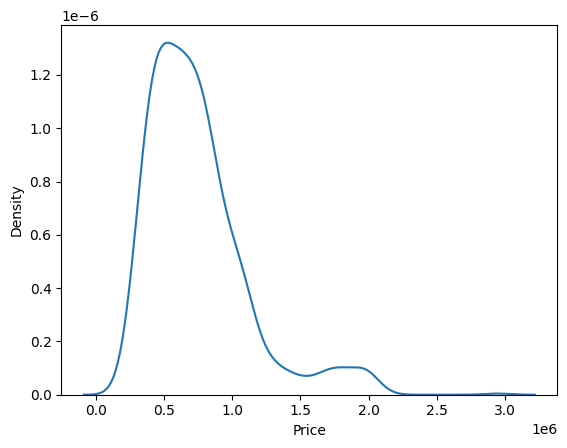

In [ ]:
# kde plot
sns.kdeplot(df, x=df['Price'])

In [12]:
df.groupby("Body_Type")["Price"].describe()

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


<Axes: xlabel='Price', ylabel='Density'>

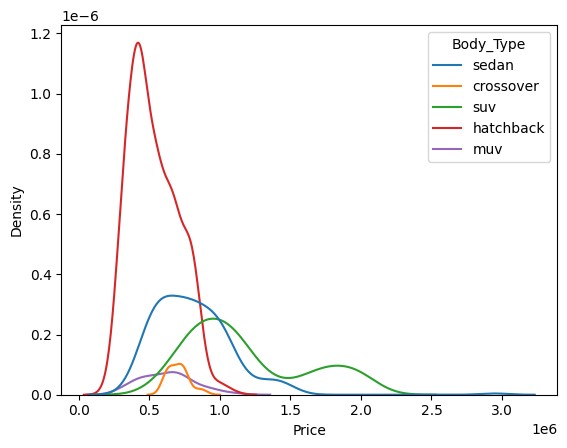

In [14]:
sns.kdeplot(df, x = df["Price"], hue = df["Body_Type"])

- The most expensive type of car seems to by the sedan/suv. 
- The car with the most variance is SUV's or sedans as well

**Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?**

In [15]:
from sklearn.linear_model import LinearRegression

X = df[["Seating_Capacity"]]
y = df["Price"]

model = LinearRegression().fit(X,y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 439032.0141018268
Slope: 59267.9980367217


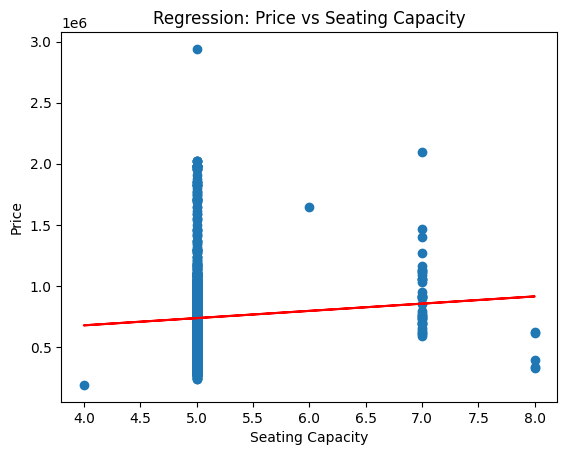

In [17]:
import matplotlib.pyplot as plt

plt.scatter(df["Seating_Capacity"], df["Price"])

# predicted line
y_pred = model.predict(X)
plt.plot(df["Seating_Capacity"], y_pred, color="red")

plt.xlabel("Seating Capacity")
plt.ylabel("Price")
plt.title("Regression: Price vs Seating Capacity")
plt.show()

- The slope coefficient is 59267, which suggests that each additional seat increases price by $59,267. This also suggests that seating capacity has a weak linear relationship to price
- From the graph, it shows that seating capacity is behaving like a categorical variable.

In [18]:
df['Seating_Capacity'].value_counts()

Seating_Capacity
5    930
7     39
8      5
6      1
4      1
Name: count, dtype: int64

In [19]:
# Treating Seating_Capacity as a one hot encoded variable
pd.get_dummies(df["Seating_Capacity"].head())

,5
0,True
1,True
2,True
3,True
4,True


In [20]:
X_Seating = pd.get_dummies(df["Seating_Capacity"], dtype=int, drop_first=True)
X_Seating.head()

,5,6,7,8
0,1,0,0,0
1,1,0,0,0
2,1,0,0,0
3,1,0,0,0
4,1,0,0,0


In [21]:
y = df["Price"]
model = LinearRegression().fit(X_Seating, y)

print("Intercept:", model.intercept_)
print(pd.DataFrame({
    "Seating Capacity": X_Seating.columns,
    "Coefficient": model.coef_
}))

Intercept: 188000.00000000163
   Seating Capacity   Coefficient
0                 5  5.464839e+05
1                 6  1.456000e+06
2                 7  7.359487e+05
3                 8  2.718000e+05


In [23]:
means = df.groupby("Seating_Capacity")["Price"].mean()
print(means)

Seating_Capacity
4    1.880000e+05
5    7.344839e+05
6    1.644000e+06
7    9.239487e+05
8    4.598000e+05
Name: Price, dtype: float64


In [24]:
diffs = means.diff()
print(diffs)

Seating_Capacity
4              NaN
5    546483.870968
6    909516.129032
7   -720051.282051
8   -464148.717949
Name: Price, dtype: float64


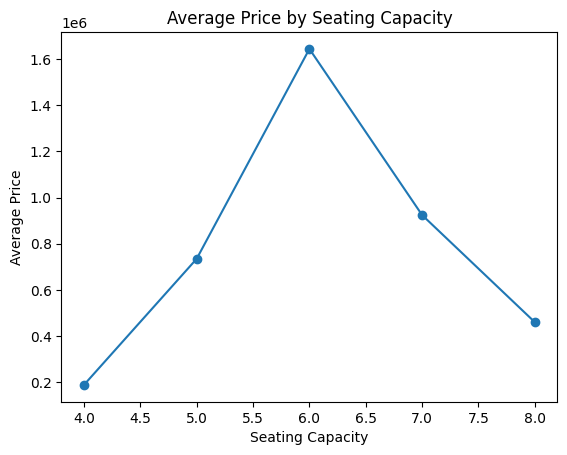

In [25]:
means.plot(marker='o')
plt.xlabel("Seating Capacity")
plt.ylabel("Average Price")
plt.title("Average Price by Seating Capacity")
plt.show()

- Prices increase sharply from 4 to 6 seats, then decrease for 7 and 8 seats. Since the consecutive differences are not similar and even change sign, the differences in price are not roughly linear in the number of seats.

**Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.**

In [52]:
# Create new variable
df['Age'] = 2024 - df['Make_Year']
df[['Make_Year', 'Age']].head()

,Make_Year,Age
0,2017,7
1,2016,8
2,2019,5
3,2017,7
4,2017,7


In [30]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Keep only needed columns and drop missing values
df_cv = df[["Age", "Price"]].dropna()

y = df_cv["Price"]
X = df_cv[["Age"]]   # must be 2D

kfold = KFold(n_splits=10, shuffle=True, random_state=100)

max_degree = 6
cv_means = []

for d in range(1, max_degree + 1):
    expander = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = expander.fit_transform(X)

    model = LinearRegression()

    scores = cross_val_score(
        model,
        X_poly,
        y,
        cv=kfold,
        scoring="neg_mean_squared_error"
    )

    scores = -scores   # make MSE positive again
    cv_means.append(np.mean(scores))

    print(f"Degree {d}")
    print("Fold scores:", scores)
    print("Mean score:", np.mean(scores))
    print("Median score:", np.median(scores))
    print("Std dev:", np.std(scores))
    print()

best_degree = np.argmin(cv_means) + 1
print("Optimal number of powers of Age:", best_degree)
print("Lowest mean CV MSE:", cv_means[best_degree - 1])

Degree 1
Fold scores: [9.05629877e+10 1.04590149e+11 8.35150173e+10 9.42889896e+10
 9.57961145e+10 8.23002081e+10 1.29209046e+11 1.10209665e+11
 7.53798399e+10 1.10087901e+11]
Mean score: 97593991873.84819
Median score: 95042552057.2941
Std dev: 15339123765.102114

Degree 2
Fold scores: [9.20679097e+10 1.04305410e+11 8.32733403e+10 9.46507501e+10
 9.54563329e+10 8.20687850e+10 1.28878082e+11 1.10133254e+11
 7.60483282e+10 1.11005506e+11]
Mean score: 97788769710.30014
Median score: 95053541488.95715
Std dev: 15213672749.608932

Degree 3
Fold scores: [9.11466665e+10 1.04301612e+11 8.26981277e+10 9.41662407e+10
 9.46269828e+10 7.93254512e+10 1.27564781e+11 1.10814361e+11
 7.64942125e+10 1.10689810e+11]
Mean score: 97182824586.8537
Median score: 94396611731.05698
Std dev: 15332240768.010555

Degree 4
Fold scores: [8.94780503e+10 1.05522986e+11 8.31725460e+10 9.23646283e+10
 9.41901237e+10 7.81577285e+10 1.28173852e+11 1.10035099e+11
 7.64254971e+10 1.09051018e+11]
Mean score: 96657152963.8

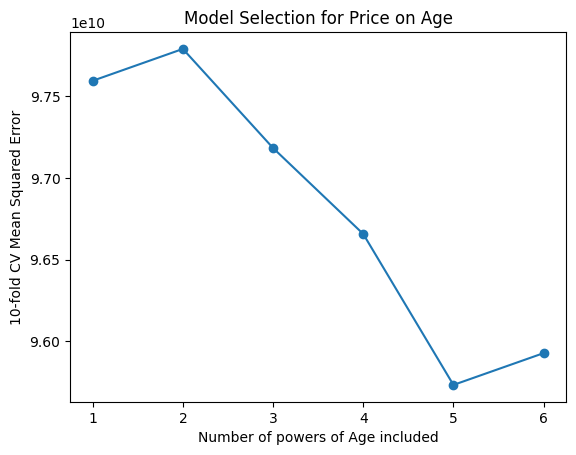

In [ ]:
# plot MSE vs. powers of Age
import matplotlib.pyplot as plt

degrees = np.arange(1, max_degree + 1)

plt.plot(degrees, cv_means, marker='o')
plt.xlabel("Number of powers of Age included")
plt.ylabel("10-fold CV Mean Squared Error")
plt.title("Model Selection for Price on Age")
plt.show()

- The model with 5 powers of Age produced the lowest mean squared error. 

**Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?**

/Users/madiheath/Documents/spring26/machine_learning/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


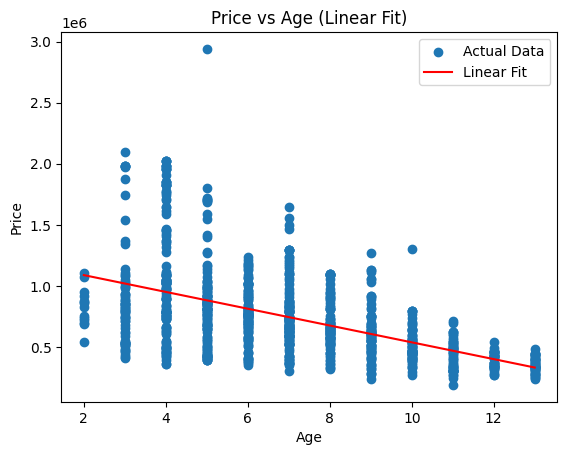

In [53]:
df_plot = df[["Age", "Price"]].dropna()
X = df_plot[["Age"]]
y = df_plot["Price"]

# fit linear model (NO polynomial features)
model = LinearRegression().fit(X, y)

# create smooth age values for plotting line
age_range = np.linspace(X["Age"].min(), X["Age"].max(), 100).reshape(-1, 1)

# predict
y_pred_line = model.predict(age_range)

# plot
plt.scatter(X, y, label="Actual Data")
plt.plot(age_range, y_pred_line, color="red", label="Linear Fit")

plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age (Linear Fit)")
plt.legend()
plt.show()

- The model captures the general downward trend in price with age, but the predicted line does not fit the data very well; the fit is imperfect, and it does not very accurately fit the patterns in the data. Because there are only specific ages of the car, there is not a good spread of data (it is only vertical lines -- not good for a linear regression model).

## Question 4

**Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?**

In [61]:
df = pd.read_csv("./data/heart_hw.csv")
df.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


In [62]:
survival_rates = df.groupby("transplant")["y"].mean()

control = survival_rates["control"]
treatment = survival_rates["treatment"]

print("Control survival rate:" , control)
print("Treatment survival rate:", treatment)

Control survival rate: 0.11764705882352941
Treatment survival rate: 0.34782608695652173


In [63]:
ATE = survival_rates["treatment"] - survival_rates["control"]
print("ATE:", ATE)

ATE: 0.23017902813299232


- The ATE on three-year survival is 0.23. This means that receiving a heart transplant changes the probability of surviving three years by 23% (this measures association, but not exactly causal effects -- there are other factors at hand)

**Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.**

In [64]:
from sklearn.linear_model import LinearRegression

# create dummy variable
# control = 0 and treatment = 1 for transplant column (makes it integer)
df["treat"] = (df["transplant"] == "treatment").astype(int)

X = df[["treat"]]   # must be 2D
y = df["y"]

model = LinearRegression().fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficient on treatment:", model.coef_[0])

Intercept: 0.11764705882352941
Coefficient on treatment: 0.23017902813299232


- The intercept is the same number as the control survival rate, and the coefficient is the same number as the ATE.
- This means that regression with a dummy variable is just computing the group mean (control) and the distance between groups (ATE).

**Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?**

In [43]:
y = df['y']
X = df[["treat", "age"]]

model = LinearRegression().fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:")
for var, coef in zip(X.columns, model.coef_):
    print(f"{var}: {coef}")

Intercept: 0.7019569721740946
Coefficients:
treat: 0.26470168650367487
age: -0.013607217160218642


- Without age, my coefficient was 0.23, and with age my transplant coefficient is 0.265, my intercept 0.702, and my age coefficient -0.0136. My transplant coefficient increases, which means when you control for age, the estimated effect of transplant becomes larger (older people are less likely to survive and maybe more likely to get a transplant??).
- The intercept represents the baseline survival probability for the control group, while the slope on transplant represents how much survival changes when receiving a transplant, holding age constant, and the slope on age represents how survival changes with age

/Users/madiheath/Documents/spring26/machine_learning/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/madiheath/Documents/spring26/machine_learning/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


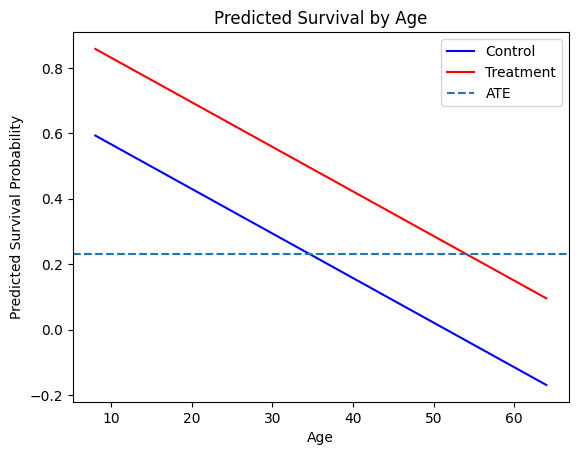

In [ ]:
# previous model
X = df[["treat", "age"]]
y = df["y"]
model = LinearRegression().fit(X, y)

# create age range
age_range = np.linspace(df["age"].min(), df["age"].max(), 100)

#predicted survival for control (treat = 0, no transplant)
X_control = np.column_stack([np.zeros(len(age_range)), age_range])
y_control = model.predict(X_control)

# treat = 1 (transplant)
X_treat = np.column_stack([np.ones(len(age_range)), age_range])
y_treat = model.predict(X_treat)

# plot
plt.plot(age_range, y_control, label="Control", color="blue")
plt.plot(age_range, y_treat, label="Treatment", color="red")

# dashed horizontal ATE line
plt.axhline(y=ATE, linestyle="--", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.title("Predicted Survival by Age")
plt.legend()
plt.show()

- The gap between the treatment and control lines is constant across age (around 0.25), indicating that the effect of transplant does not vary with age in this model. The ATE is smaller than this constant effect, so it underestimates the impact of a transplant at all ages.

**Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?**

/Users/madiheath/Documents/spring26/machine_learning/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/madiheath/Documents/spring26/machine_learning/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


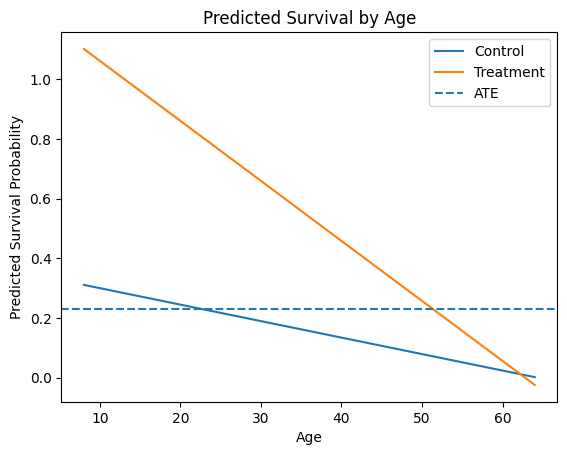

In [69]:
df["treat_age"] = df["treat"] * df["age"]

X = df[["treat", "age", "treat_age"]]
y = df["y"]

model = LinearRegression().fit(X, y)

age_range = np.linspace(df["age"].min(), df["age"].max(), 100)

# control predictions
y_control = model.predict(
    np.column_stack([np.zeros_like(age_range), age_range, np.zeros_like(age_range)])
)

# treatment predictions
y_treat = model.predict(
    np.column_stack([np.ones_like(age_range), age_range, age_range])
)

plt.plot(age_range, y_control, label="Control")
plt.plot(age_range, y_treat, label="Treatment")
plt.axhline(y=ATE, linestyle="--", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.title("Predicted Survival by Age")
plt.legend()
plt.show()

- realized the question doesn't ask for a graph, but I just left it anyway

In [71]:
y = df['y']
X = df[["treat", "age", "treat_age"]]

model = LinearRegression().fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:")
for var, coef in zip(X.columns, model.coef_):
    print(f"{var}: {coef}")

Intercept: 0.35486517529945866
Coefficients:
treat: 0.9077513885685893
age: -0.005524257506973695
treat_age: -0.014590638256855278


- The intercept changes from 0.7 to 0.35 (decreases dramatically). The transplant coefficient changes from 0.26 to 0.91, the age coefficient changes from -0.014 to -0.006, and the new transplant * age coefficient is -0.015.
- These changes show that the effect of a transplant is no longer constant but depends on age. The negative age coefficient suggests that the benefit of transplant decreases as age increases. Survival based on aging decreases even more (-0.021) for people who receive a transplant (they are more likely to die) compared to the group with no transplant (-0.06).

**Use 10-fold cross validation to evaluate the predictive accuracy of these models.**

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

y = df['y']
X = df[["treat", "age", "treat_age"]]

kfold = KFold(n_splits=10, shuffle=True, random_state=100) # Create folds

scores = cross_val_score( # Conduct kfcv:
    model,X,y, # Model and data
    cv=kfold, # Folds
    scoring="neg_mean_squared_error" # Loss function
)
scores = -scores

print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))

Fold scores: [0.13045006 0.09902894 0.233215   0.25380574 0.27583732 0.11557048
 0.12649585 0.20870022 0.14792529 0.21568012]
Mean score: 0.18067090272965364
Median score: 0.17831275470716962
Std dev: 0.0605064791938699


- the model's average MSE is 0.181

**Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?**

- This model only focuses on age and transplant, even if other variables were added it might become too complex (overfitting). It is difficult to understand how certain factors like access to care, healthiness, and other important characteristics that play a part in who should get a transplant would be added in (asking "who should get the transplant" is also a very controversial and a heavily weighted decision -- there are a lot of requirements that individuals have to suffer through to be deemed qualified). 
- This model is also not causal. It does not truly answer who should get a transplant; it only analyzes the patterns that exist in the data.
- The model shows that transplant works less with age, but this could just represent selection effects (older patients are probably already sicker). This could lead to a lot of older patients being denied transplants with disadvantaged groups getting less care (also leads to a lot of ethical questions: Should younger patients always be prioritized, etc...?).
- Doctors could also use this model as the objective truth, but these decisions are at very high stakes and based on limited variables.